In [62]:
import os
import csv
import zlib
import bz2
import lzma
import gzip

In [63]:
# ===============================
# Config
# ===============================
INPUT_FOLDER = "./data/medias_txt"
OUTPUT_CSV = "results/compression_scores_media.csv"

# ===============================
# Fonction pour traiter un fichier (avec plusieurs algorithmes)
# ===============================
def process_file(file_path, max_length=None, verbose=False, algorithm='zlib'):
    # Essayer différents encodages
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    text = None
    
    for encoding in encodings:
        try:
            with open(file_path, "r", encoding=encoding) as f:
                text = f.read()
            break
        except UnicodeDecodeError:
            continue
    
    if text is None:
        # En dernier recours, lire avec errors='ignore'
        with open(file_path, "r", encoding='utf-8', errors='ignore') as f:
            text = f.read()
    
    original_length = len(text)
    
    # Tronquer le texte si max_length est spécifié
    if max_length is not None and len(text) > max_length:
        text = text[:max_length]

    data = text.encode('utf-8')
    original_size = len(data)
    
    # Choisir l'algorithme de compression
    if algorithm == 'zlib':
        compressed_size = len(zlib.compress(data))
    elif algorithm == 'bz2':
        compressed_size = len(bz2.compress(data))
    elif algorithm == 'lzma':
        compressed_size = len(lzma.compress(data))
    elif algorithm == 'gzip':
        compressed_size = len(gzip.compress(data))
    else:
        raise ValueError(f"Algorithme non supporté: {algorithm}")
    
    info_score = compressed_size / original_size
    
    if verbose:
        return info_score, original_length, len(text)
    return info_score

# ===============================
# Fonction pour traiter un dossier entier
# ===============================
def process_txt_folder(input_folder=INPUT_FOLDER, output_csv=OUTPUT_CSV, max_length=None, 
                       verbose=False, sort_results=True, algorithm='zlib', compare_algorithms=False):
    """
    Traite un dossier de fichiers texte et calcule leur score de compression
    
    Parameters:
    - compare_algorithms: Si True, teste les 4 algorithmes et affiche un tableau comparatif
    - algorithm: Si compare_algorithms=False, l'algorithme à utiliser ('zlib', 'bz2', 'lzma', 'gzip')
    """
    
    txt_files = [f for f in os.listdir(input_folder) if f.endswith(".txt")]
    
    if compare_algorithms:
        # Mode comparaison: tester tous les algorithmes
        algos = ['zlib', 'bz2', 'lzma', 'gzip']
        results_by_algo = {algo: [] for algo in algos}
        
        truncate_msg = f" (tronqué à {max_length:,} caractères)" if max_length else ""
        print(f"🔬 Comparaison de {len(algos)} algorithmes sur {len(txt_files)} fichiers{truncate_msg}\n")
        
        for file_name in txt_files:
            file_path = os.path.join(input_folder, file_name)
            for algo in algos:
                score = process_file(file_path, max_length=max_length, algorithm=algo)
                results_by_algo[algo].append((file_name.replace(".txt", ""), score))
        
        # Afficher le tableau comparatif
        print(f"\n📈 TABLEAU COMPARATIF (du MOINS au PLUS compressible)\n")
        print(f"{'Texte':30s} | {'zlib':>10s} | {'bz2':>10s} | {'lzma':>10s} | {'gzip':>10s} | {'Moyenne':>10s}")
        print("-" * 95)
        
        # Organiser par fichier
        file_scores = {}
        for algo in algos:
            for file_name, score in results_by_algo[algo]:
                if file_name not in file_scores:
                    file_scores[file_name] = {}
                file_scores[file_name][algo] = score
        
        # Trier par score moyen (moins compressible d'abord)
        sorted_files = sorted(file_scores.keys(), 
                              key=lambda x: sum(file_scores[x].values())/len(algos), 
                              reverse=True)
        
        for i, file_name in enumerate(sorted_files, 1):
            scores = file_scores[file_name]
            avg = sum(scores.values()) / len(algos)
            print(f"{i}. {file_name:27s} | {scores['zlib']:10.6f} | {scores['bz2']:10.6f} | {scores['lzma']:10.6f} | {scores['gzip']:10.6f} | {avg:10.6f}")
        
    else:
        # Mode simple: un seul algorithme
        results = []
        truncate_msg = f" (tronqué à {max_length:,} caractères)" if max_length else ""
        print(f"Processing {len(txt_files)} files with {algorithm.upper()}{truncate_msg}...\n")
        
        for file_name in txt_files:
            file_path = os.path.join(input_folder, file_name)
            
            if verbose:
                score, original_length, final_length = process_file(file_path, max_length=max_length, 
                                                                    verbose=True, algorithm=algorithm)
                results.append((file_name.replace(".txt", ""), score, original_length, final_length))
            else:
                score = process_file(file_path, max_length=max_length, algorithm=algorithm)
                results.append((file_name.replace(".txt", ""), score))
        
        # Trier par score (du moins au plus compressible = score décroissant)
        if sort_results:
            results.sort(key=lambda x: x[1], reverse=True)
        
        # Afficher les résultats
        print("📊 Résultats (du MOINS au PLUS compressible):\n")
        for i, result in enumerate(results, 1):
            if verbose:
                file_name, score, original_length, final_length = result
                truncated = " [TRONQUÉ]" if original_length > final_length else ""
                print(f"{i}. {file_name:30s} -> {original_length:>9,} → {final_length:>9,} car. | Info: {score:.6f}{truncated}")
            else:
                file_name, score = result
                print(f"{i}. {file_name:30s} -> Info score: {score:.6f}")
        
        # Sauvegarder CSV (sans les colonnes verbose)
        with open(output_csv, "w", newline="", encoding="utf-8") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(["media", "info_score"])
            for result in results:
                writer.writerow([result[0], result[1]])
        
        print(f"\n✅ Scores saved to {output_csv}")


In [64]:
# utilisation sur les extraits de presse

process_txt_folder()

process_txt_folder(algorithm='bz2')

Processing 26 files with ZLIB...

📊 Résultats (du MOINS au PLUS compressible):

1. TMZ                            -> Info score: 0.409767
2. Refinery 29                    -> Info score: 0.403188
3. Vice                           -> Info score: 0.402093
4. Mashable                       -> Info score: 0.397946
5. Hyperallergic                  -> Info score: 0.397892
6. New Yorker                     -> Info score: 0.396216
7. People                         -> Info score: 0.395375
8. Economist                      -> Info score: 0.393842
9. New Republic                   -> Info score: 0.390668
10. Washington Post                -> Info score: 0.390028
11. Reuters                        -> Info score: 0.390019
12. Axios                          -> Info score: 0.386949
13. The Verge                      -> Info score: 0.385174
14. Gizmodo                        -> Info score: 0.384247
15. Fox News                       -> Info score: 0.381461
16. Wired                          -> Info s

In [65]:
# validation de la méthode avec comparaison des algorithmes

INPUT_FOLDER_validation = "./data/textes_pour_compression"
OUTPUT_CSV_validation = "results/compression_scores_validation.csv"

process_txt_folder(input_folder=INPUT_FOLDER_validation, output_csv=OUTPUT_CSV_validation, 
                   max_length=999999999, compare_algorithms=True)

print("\n" * 3)

process_txt_folder(input_folder=INPUT_FOLDER_validation, output_csv=OUTPUT_CSV_validation, 
                   max_length=89_703, compare_algorithms=True)


🔬 Comparaison de 4 algorithmes sur 6 fichiers (tronqué à 999,999,999 caractères)


📈 TABLEAU COMPARATIF (du MOINS au PLUS compressible)

Texte                          |       zlib |        bz2 |       lzma |       gzip |    Moyenne
-----------------------------------------------------------------------------------------------
1. temps_perdu                 |   0.372940 |   0.273762 |   0.299489 |   0.371218 |   0.329352
2. harry_potter1               |   0.367038 |   0.269935 |   0.307727 |   0.365556 |   0.327564
3. 2000_lieux                  |   0.372751 |   0.265834 |   0.294020 |   0.371372 |   0.325994
4. relativity                  |   0.343575 |   0.260160 |   0.266682 |   0.342436 |   0.303213
5. algebre                     |   0.337662 |   0.266766 |   0.270586 |   0.336220 |   0.302809
6. petit_prince                |   0.306154 |   0.245295 |   0.277211 |   0.303843 |   0.283126




🔬 Comparaison de 4 algorithmes sur 6 fichiers (tronqué à 89,703 caractères)


📈 TABLEAU COM

In [66]:
# Déterminer la longueur des textes dans textes_pour_compression

folder = "./data/textes_pour_compression"
txt_files = [f for f in os.listdir(folder) if f.endswith(".txt")]

print("Longueur des textes (en caractères):\n")
for file_name in txt_files:
    file_path = os.path.join(folder, file_name)
    
    # Essayer différents encodages
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    text = None
    
    for encoding in encodings:
        try:
            with open(file_path, "r", encoding=encoding) as f:
                text = f.read()
            break
        except UnicodeDecodeError:
            continue
    
    if text is None:
        with open(file_path, "r", encoding='utf-8', errors='ignore') as f:
            text = f.read()
    
    length = len(text)
    print(f"{file_name:25s} -> {length:,} caractères")


Longueur des textes (en caractères):

relativity.txt            -> 1,452,308 caractères
algebre.txt               -> 1,257,153 caractères
temps_perdu.txt           -> 1,006,879 caractères
petit_prince.txt          -> 89,703 caractères
harry_potter1.txt         -> 442,745 caractères
2000_lieux.txt            -> 876,841 caractères


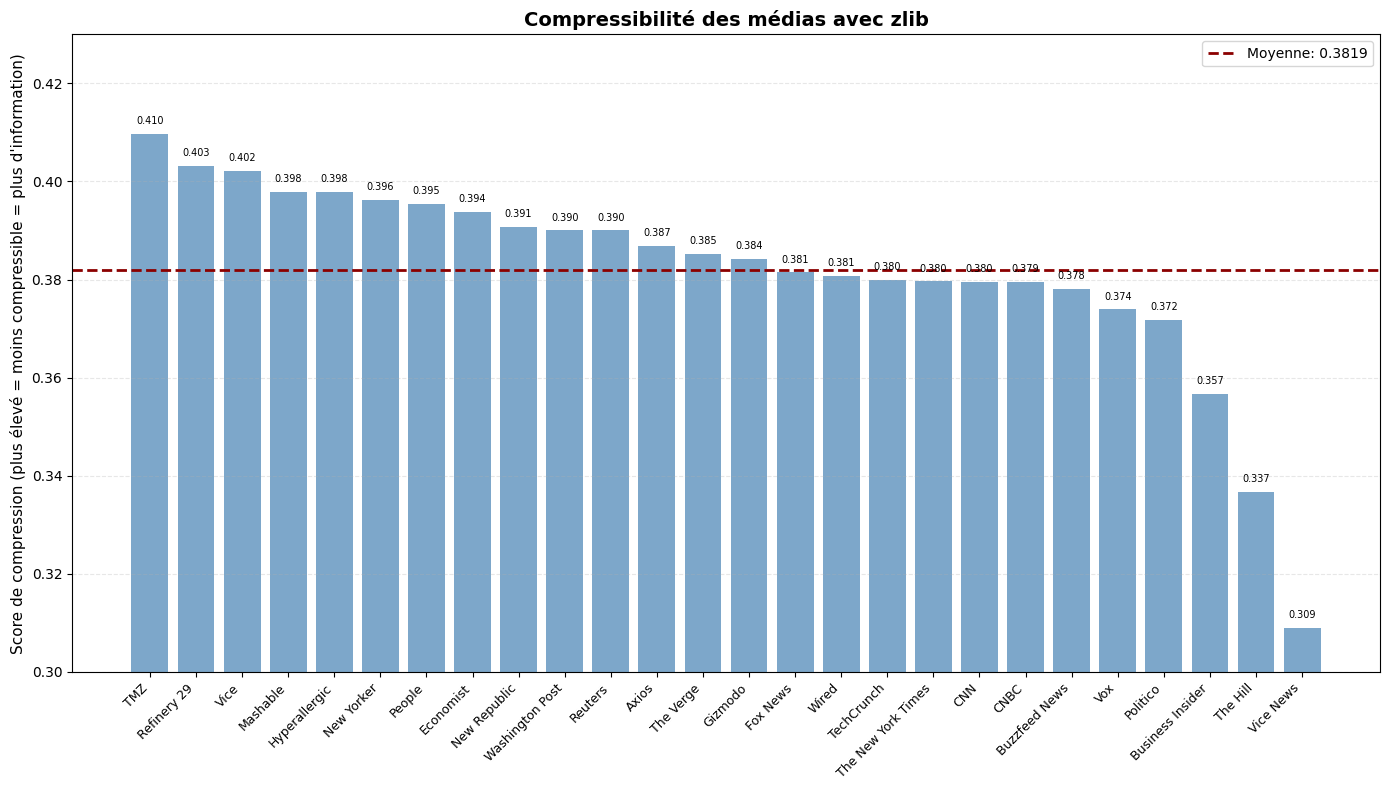


📊 Statistiques:
   Moyenne: 0.381940
   Min: 0.308990 (Vice News)
   Max: 0.409767 (TMZ)
   Écart: 0.100777


In [72]:
import matplotlib.pyplot as plt

# Données des médias
medias = [
    "TMZ", "Refinery 29", "Vice", "Mashable", "Hyperallergic", "New Yorker", 
    "People", "Economist", "New Republic", "Washington Post", "Reuters", "Axios",
    "The Verge", "Gizmodo", "Fox News", "Wired", "TechCrunch", "The New York Times",
    "CNN", "CNBC", "Buzzfeed News", "Vox", "Politico", "Business Insider", 
    "The Hill", "Vice News"
]

scores = [
    0.409767, 0.403188, 0.402093, 0.397946, 0.397892, 0.396216,
    0.395375, 0.393842, 0.390668, 0.390028, 0.390019, 0.386949,
    0.385174, 0.384247, 0.381461, 0.380757, 0.379981, 0.379618,
    0.379517, 0.379491, 0.378105, 0.373932, 0.371750, 0.356699,
    0.336745, 0.308990
]

# Créer le graphique avec barres verticales
fig, ax = plt.subplots(figsize=(14, 8))

# Barres verticales
bars = ax.bar(range(len(medias)), scores, color='steelblue', alpha=0.7)

# Ajouter les valeurs sur les barres
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax.text(i, score + 0.002, f'{score:.3f}', ha='center', fontsize=7, rotation=0)

# Configuration du graphique
ax.set_ylabel('Score de compression (plus élevé = moins compressible = plus d\'information)', fontsize=11)
ax.set_title('Compressibilité des médias avec zlib', fontsize=14, fontweight='bold')
ax.set_ylim(0.30, 0.43)
ax.set_xticks(range(len(medias)))
ax.set_xticklabels(medias, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Ajouter une ligne horizontale pour la moyenne
mean_score = sum(scores) / len(scores)
ax.axhline(mean_score, color='darkred', linestyle='--', linewidth=2, label=f'Moyenne: {mean_score:.4f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Statistiques:")
print(f"   Moyenne: {mean_score:.6f}")
print(f"   Min: {min(scores):.6f} (Vice News)")
print(f"   Max: {max(scores):.6f} (TMZ)")
print(f"   Écart: {max(scores) - min(scores):.6f}")
